Lasso Regression:

**Y = wX + b**

Y --> Dependent Variable

X --> Independent Variable

w --> weight

b --> bias

**Gradient Descent:**

Gradient Descent is an optimization algorithm used for minimizing the loss function in various machine learning algorithms. It is used for updating the parameters of the learning model.

w  =  w - α*dw

b  =  b - α*db

**Learning Rate:**

Learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.

Gradient for Weights

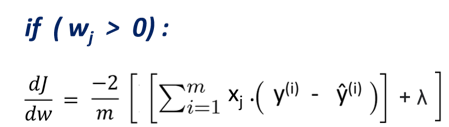

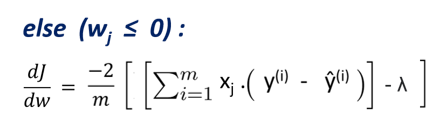

Gradient for Bias

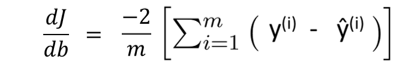

Lasso Regression

In [30]:
import numpy as np
# creating a class for Lasso Regression

class Lasso_Regression():

  #initiating the hyperparameters
  def __init__(self, learning_rate, no_of_iterations, lambda_parameter):

    self.learning_rate = learning_rate
    self.no_of_iterations = no_of_iterations
    self.lambda_parameter = lambda_parameter


  # fitting the dataset to the Lasso Regression model
  def fit(self, X, Y):

    # m --> number of Data points --> number of rows
    # n --> number of input features --> number of columns
    self.m, self.n = X.shape

    self.w = np.zeros(self.n)

    self.b = 0

    self.X = X

    self.Y = Y

    # implementing Gradient Descent algorithm for Optimization

    for i in range(self.no_of_iterations):
      self.upadte_weights()


  # function for updating the weight & bias value
  def upadte_weights(self):

    # linear equation of the model
    Y_prediction = self.predict(self.X)

    # gradients (dw, db)

    # gradient for weight
    dw = np.zeros(self.n)

    for i in range(self.n):

      if self.w[i]>0:

        dw[i] = (-(2*(self.X[:,i]).dot(self.Y - Y_prediction)) + self.lambda_parameter) / self.m

      else :

        dw[i] = (-(2*(self.X[:,i]).dot(self.Y - Y_prediction)) - self.lambda_parameter) / self.m


    # gradient for bias
    db = - 2 * np.sum(self.Y - Y_prediction) / self.m


    # updating the weights & bias
    self.w = self.w - self.learning_rate*dw
    self.b = self.b - self.learning_rate*db



  # Predicting the Target variable
  def predict(self,X):
    return X.dot(self.w) + self.b

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [32]:
dia_data = pd.read_csv('/content/diabetes.csv')

In [33]:
dia_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [34]:
feature = dia_data.drop(columns='Outcome', axis=1)

In [35]:
scaler = StandardScaler()

In [36]:
scaler.fit(feature)

StandardScaler()

In [37]:
std_data = scaler.transform(feature)

In [38]:
feature = std_data
target = dia_data['Outcome']

In [39]:
xtrain, xtest, ytrain, ytest = train_test_split(feature, target, test_size=0.2, random_state=2)

In [45]:
print(xtrain.shape, xtest.shape, ytrain.shape, ytest.shape)

(614, 8) (154, 8) (614,) (154,)


In [40]:
model = Lasso_Regression(learning_rate=0.02, no_of_iterations=1000, lambda_parameter=0.01)

In [41]:
model.fit(xtrain, ytrain)

In [42]:
ytrainpredicted = model.predict(xtrain)

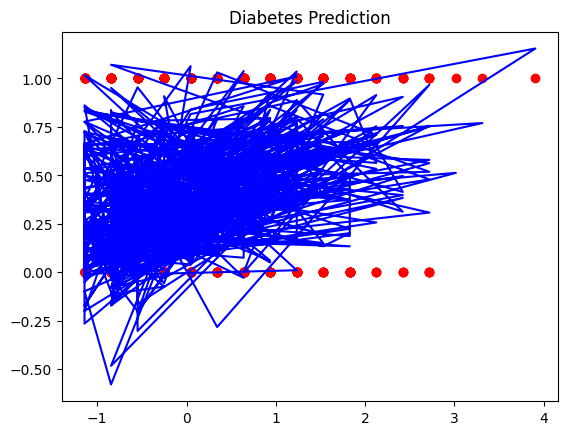

In [49]:
plt.scatter(xtrain[:, 0], ytrain, color='red')
plt.plot(xtrain[:, 0], ytrainpredicted, color='blue')
plt.title('Diabetes Prediction')
plt.show()

# Not a good representer